# Описание задачи

Системы проката велосипедов — это способ аренды велосипедов, при котором процесс оформления членства, аренды и возврата велосипеда автоматизирован через сеть киосков, расположенных по всему городу. Используя эти системы, люди могут арендовать велосипед в одном месте и вернуть его в другом месте по мере необходимости. В настоящее время в мире существует более 500 программ проката велосипедов.

Данные, генерируемые этими системами, делают их привлекательными для исследователей, поскольку в них четко регистрируются продолжительность поездки, место отправления, место прибытия и прошедшее время. Таким образом, системы проката велосипедов функционируют как сенсорная сеть, которую можно использовать для изучения мобильности в городе. В этом конкурсе участникам предлагается объединить исторические данные об использовании с данными о погоде, чтобы спрогнозировать спрос на прокат велосипедов в рамках программы Capital Bikeshare в Вашингтоне, округ Колумбия.

# Данные

Исходный файл: train.csv (для обучения модели).

# Структура данных

# Целевая переменная:
- count — общее количество аренд велосипедов за час.

# Признаки:
   - # Временные:
     - datetime — дата и время (исходный столбец);
     - season — сезон (1 = весна, 2 = лето, 3 = осень, 4 = зима);
     - holiday — является ли день праздником (0/1);
     - workingday — рабочий ли день (0/1).
   - # Погодные:
      - temp — температура воздуха (°C);
      - atemp — «ощущаемая» температура (°C);
      - humidity — влажность воздуха (%);
      - windspeed — скорость ветра (км/ч);
      - weather — категория погоды (1 = ясно/облачно, 2 = небольшой дождь/снег, 3 = умеренный дождь/снег, 4 = сильный дождь/снег/гроза/туман).

# Оценка:  RMSLE



# Установка и импорт библиотек:

In [154]:
from matplotlib import pyplot as plt
!pip install phik -q

In [155]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1) Загрузка данных

In [156]:
data = pd.read_csv('train.csv')

In [157]:
print(data.head())

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


In [137]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB
None


# 2) Предобработка и исследовательский анализ

In [158]:
print(data.isnull().sum())

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [159]:
duplicates = data[data.duplicated()]
if len(duplicates) > 0:
    print(duplicates)
else:
    print('No duplicates')

No duplicates


# 3) Извлечь временные признаки из datetime (year, month, day, hour, weekday)

In [160]:
def extract_datetime_features(df, drop_original = True):

    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['hour'] = df['datetime'].dt.hour
    df['weekday'] = df['datetime'].dt.weekday
    df['is_weekend'] = (df['weekday'] >= 5).astype(int)

    if drop_original:
        df.drop(['datetime'], axis=1, inplace=True)
    return df


data = extract_datetime_features(data, drop_original = True)


In [161]:
print("\nНовые столбцы после извлечения признаков:")
print(data[['year', 'month', 'day', 'hour', 'weekday']].head())

print("\nТипы данных после преобразования:")
print(data.dtypes)


Новые столбцы после извлечения признаков:
   year  month  day  hour  weekday
0  2011      1    1     0        5
1  2011      1    1     1        5
2  2011      1    1     2        5
3  2011      1    1     3        5
4  2011      1    1     4        5

Типы данных после преобразования:
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
year            int32
month           int32
day             int32
hour            int32
weekday         int32
is_weekend      int64
dtype: object


# 4) Рассчитать корреляции с count и выявить признаки, которые приводят к утечке данных

In [162]:
correlation_matrix = data.corr()

In [163]:
print(correlation_matrix['count'].sort_values(ascending = False))

count         1.000000
registered    0.970948
casual        0.690414
hour          0.400601
temp          0.394454
atemp         0.389784
year          0.260403
month         0.166862
season        0.163439
windspeed     0.101369
day           0.019826
workingday    0.011594
weekday      -0.002283
holiday      -0.005393
is_weekend   -0.009925
weather      -0.128655
humidity     -0.317371
Name: count, dtype: float64


In [164]:
print(correlation_matrix)

              season   holiday  workingday   weather      temp     atemp  \
season      1.000000  0.029368   -0.008126  0.008879  0.258689  0.264744   
holiday     0.029368  1.000000   -0.250491 -0.007074  0.000295 -0.005215   
workingday -0.008126 -0.250491    1.000000  0.033772  0.029966  0.024660   
weather     0.008879 -0.007074    0.033772  1.000000 -0.055035 -0.055376   
temp        0.258689  0.000295    0.029966 -0.055035  1.000000  0.984948   
atemp       0.264744 -0.005215    0.024660 -0.055376  0.984948  1.000000   
humidity    0.190610  0.001929   -0.010880  0.406244 -0.064949 -0.043536   
windspeed  -0.147121  0.008409    0.013373  0.007261 -0.017852 -0.057473   
casual      0.096758  0.043799   -0.319111 -0.135918  0.467097  0.462067   
registered  0.164011 -0.020956    0.119460 -0.109340  0.318571  0.314635   
count       0.163439 -0.005393    0.011594 -0.128655  0.394454  0.389784   
year       -0.004797  0.012021   -0.002482 -0.012548  0.061226  0.058540   
month       

# 5) Подготовка данных

In [165]:
features = ['count', 'month', 'is_weekend', 'casual', 'registered']
X = data.drop(features, axis=1)
y = data['count']

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# 6) Обучение модели

In [167]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# LinearRegression

In [168]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

# RandomForest

In [169]:
model_rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

# CatBoost

In [170]:
model_cb = CatBoostRegressor(iterations=1000, random_state=42, learning_rate=0.1, depth=6, loss_function='RMSE', verbose=100)
model_cb.fit(X_train, y_train)
y_pred_cb = model_cb.predict(X_test)

0:	learn: 170.3863789	total: 1.89ms	remaining: 1.89s
100:	learn: 45.7218640	total: 73.4ms	remaining: 653ms
200:	learn: 38.1686472	total: 142ms	remaining: 563ms
300:	learn: 34.3622249	total: 212ms	remaining: 492ms
400:	learn: 31.7845868	total: 278ms	remaining: 416ms
500:	learn: 29.7109302	total: 350ms	remaining: 349ms
600:	learn: 28.1612544	total: 421ms	remaining: 279ms
700:	learn: 26.9388071	total: 496ms	remaining: 212ms
800:	learn: 25.7562669	total: 569ms	remaining: 141ms
900:	learn: 24.7524735	total: 644ms	remaining: 70.8ms
999:	learn: 23.9069398	total: 714ms	remaining: 0us


# XGBoost

In [171]:
model_xgb = XGBRegressor(n_estimators=1000, learning_rate=0.1, random_state = 42, max_depth=6)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

# 7) Оценка RMSLE

In [172]:
RMSLE_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"RMSE_LR: {RMSLE_lr}")

RMSLE_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RMSE_RF: {RMSLE_rf}")

RMSLE_cb = np.sqrt(mean_squared_error(y_test, y_pred_cb))
print(f"RMSE_CB: {RMSLE_cb}")

RMSLE_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"RMSE_XGB: {RMSLE_xgb}")

RMSE_LR: 141.39195162962446
RMSE_RF: 39.520363213664226
RMSE_CB: 35.61405577846017
RMSE_XGB: 36.21292217457568


# 8) Визуализация результатов

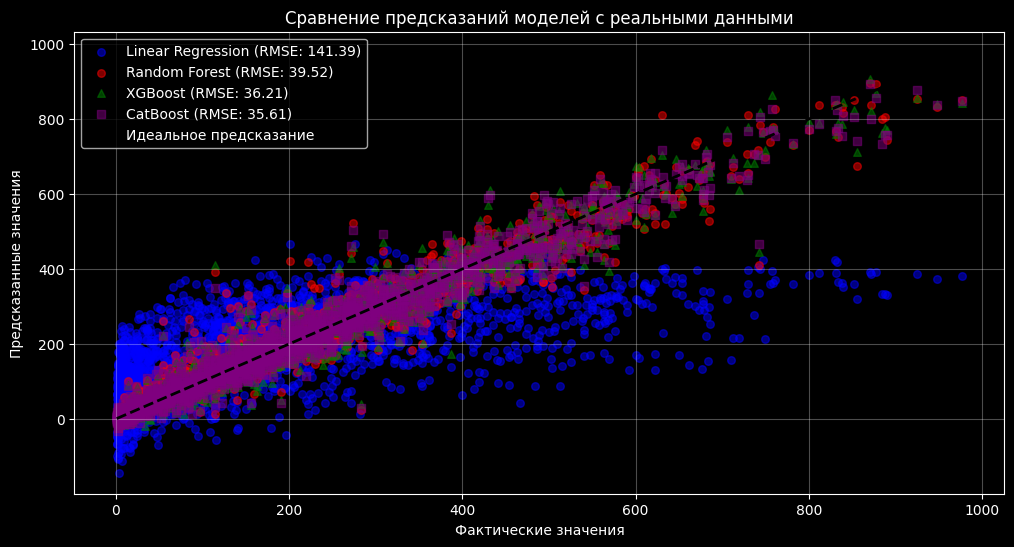

In [175]:
plt.figure(figsize=(12, 6))

# Linear Regression
plt.scatter(y_test, y_pred_lr, alpha=0.5, label=f'Linear Regression (RMSE: {RMSLE_lr:.2f})', color='blue', s=30)

# Random Forest
plt.scatter(y_test, y_pred_rf, alpha=0.5, label=f'Random Forest (RMSE: {RMSLE_rf:.2f})', color='red', s=30)

# XGBoost
plt.scatter(y_test, y_pred_xgb, alpha=0.5, label=f'XGBoost (RMSE: {RMSLE_xgb:.2f})', color='green', s=30, marker='^')

# CatBoost
plt.scatter(y_test, y_pred_cb, alpha=0.5, label=f'CatBoost (RMSE: {RMSLE_cb:.2f})', color='purple', s=30, marker='s')

# Идеальная линия предсказаний
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Идеальное предсказание')

plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Сравнение предсказаний моделей с реальными данными')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


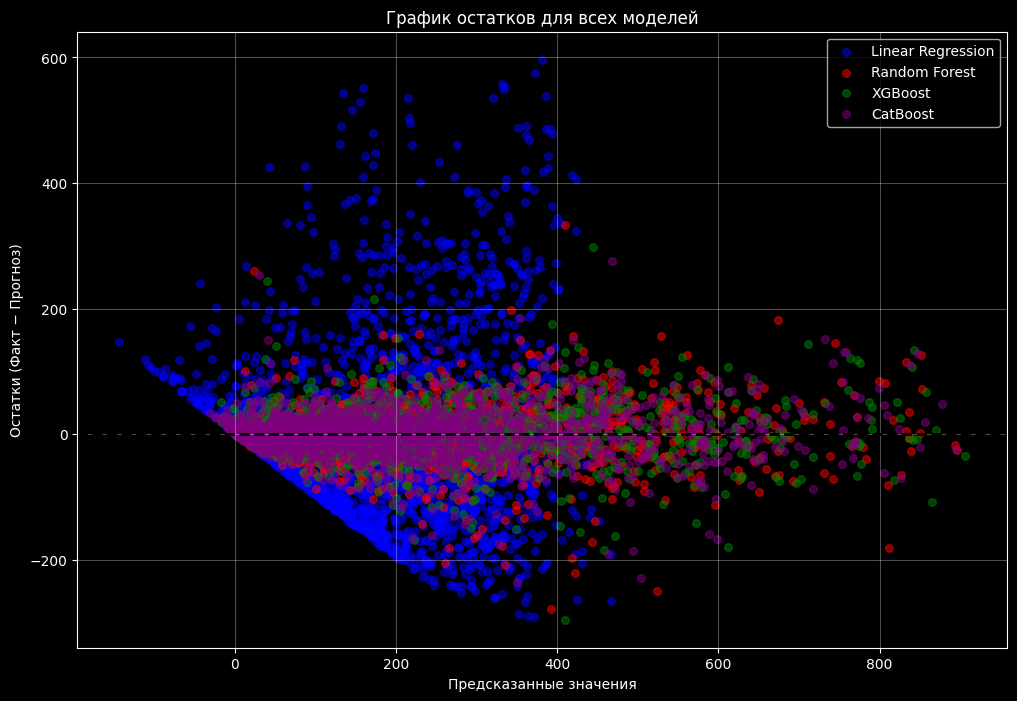

In [176]:
plt.figure(figsize=(12, 8))

models = [
    (y_pred_lr, 'Linear Regression', 'blue'),
    (y_pred_rf, 'Random Forest', 'red'),
    (y_pred_xgb, 'XGBoost', 'green'),
    (y_pred_cb, 'CatBoost', 'purple')
]

for pred, name, color in models:
    residuals = y_test - pred
    plt.scatter(pred, residuals, alpha=0.5, label=name, color=color, s=30)

plt.axhline(y=0, color='k', linestyle='--', linewidth=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки (Факт − Прогноз)')
plt.title('График остатков для всех моделей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


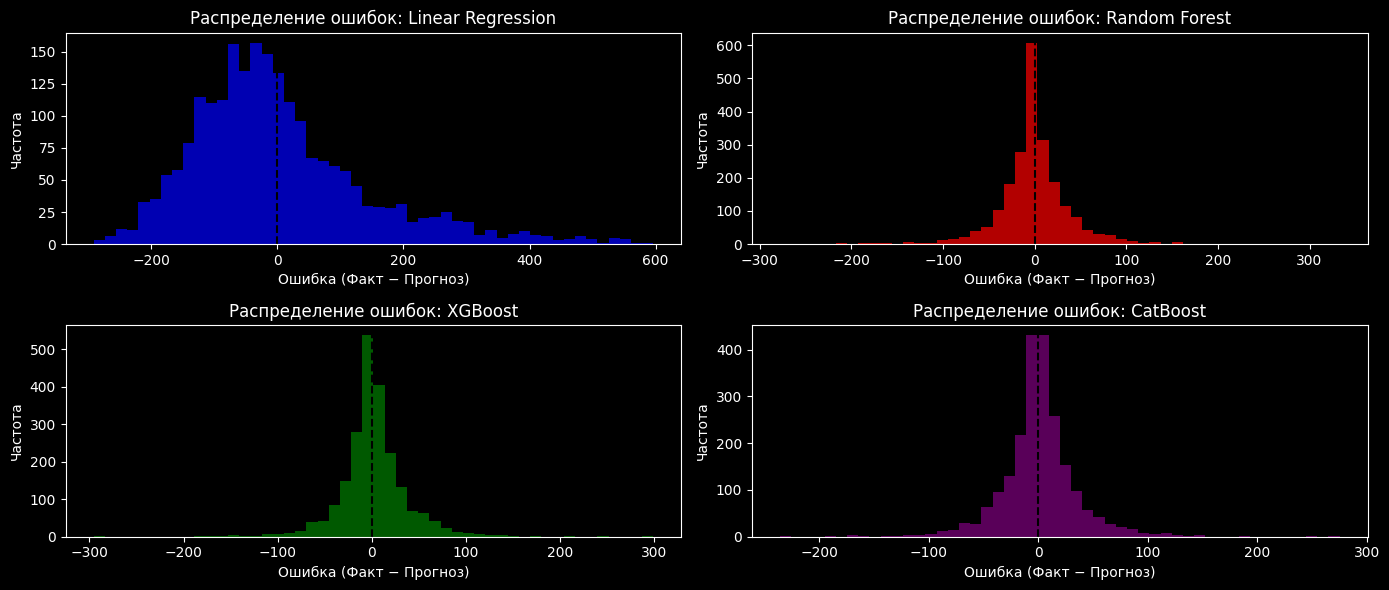

In [177]:
plt.figure(figsize=(14, 6))

for i, (pred, name, color) in enumerate(models, 1):
    errors = y_test - pred
    plt.subplot(2, 2, i)
    plt.hist(errors, bins=50, alpha=0.7, color=color)
    plt.title(f'Распределение ошибок: {name}')
    plt.xlabel('Ошибка (Факт − Прогноз)')
    plt.ylabel('Частота')
    plt.axvline(x=0, color='k', linestyle='--')

plt.tight_layout()
plt.show()


# Вывод

Проект выполнился в несколько этапов:
1. Загрузка данных
- Ознакомление с данными проведено успешно. Данные соответствуют с описанием задачи.

- Проведена первичная проверка структуры датафрейма: количество строк, столбцов, типы данные
2. Исследовательский анализ и предобработка данных
- Выполнен анализ пропусков — выявлены и обработаны пропущенные значения в ключевых признаках.

- Проверены и удалены дубликаты записей.

3. Извлечены временные признаки из datetime

- year(год)

- day(день)

- month(месяц)

- hour(часы)

- weekday(будний день)

4. Рассчитать корреляции с count и выявить признаки, которые приводят к утечке данных

- casual и registered - имеют утечку данных и маловажные признаки для обучения.

- weekday и is_weekend - дубалируют друг друга можно удалить один из признаков

- month и season - можно убрать один из двух, но предпочел взять season(времена года)

5. Подготовка данных

- Не нужные признаки ['count', 'month', 'is_weekend', 'casual', 'registered'] убрал из X переменной

- Целевой признак: count

- Использован `StandartScaler` масштабирование, так как `LinearRegression` для получение лучшего результата

6. Обучение модели

- Модели были обучены с помощью(`LinearRegression`, `RandomForest`, `XGBoost`, `CatBoost`)

- Лучшими моделями оказались `XGBoost` и `CatBoost`, `CatBoost` незначительно, но показали результат лучше чем `XGBoost`

7.  Оценка модели с помощью RMSLE(указано в условие задачи)

- В результате оценки с помощью RMSLE  `CatBoost` = 35.61405577846017

- `XGBoost` = 36.21292217457568

- `RandomForest` = 39.520363213664226

- `LinearRegression` = 141.39195162962446

8. Визуализация результатов

1) Результат диаграммы рассеяния

# `LinearRegression`

- Точки (синие кружки) сильно отклоняются от линии идеального предсказания, особенно в диапазоне высоких значений.

- Большой разброс указывает на низкую точность модели.

- Высокий RMSE (141.39) подтверждает, что эта модель наименее точна среди представленных.

- Вероятно, линейная модель не улавливает сложные нелинейные зависимости в данных.

# `RandomForest`

- Точки (красные кружки) ближе к линии идеального предсказания по сравнению с линейной регрессией.

- Разброс меньше, чем у Linear Regression, но заметен в области высоких значений.

- RMSE (39.52) значительно ниже, чем у линейной регрессии, что говорит о лучшей точности.

- Модель хорошо работает с большинством данных, но имеет сложности с крайними значениями.

# `XGBoost`

- Точки (зелёные треугольники) очень близки к линии идеального предсказания.

- Разброс минимальный, распределение точек компактное.

- RMSE (36.21) — один из лучших результатов.

- Модель демонстрирует высокую точность и стабильность, хорошо улавливает закономерности в данных.

# `CatBoost`

- Точки (фиолетовые квадраты) практически лежат на линии идеального предсказания.

- Наименьший разброс среди всех моделей.

- RMSE (35.61) — наименьший из представленных, что делает CatBoost самой точной моделью.

- Отлично справляется как с низкими, так и с высокими значениями целевой переменной.

2) График остатков для всех моделей

# `LinearRegression`(синие)

- Много точек с большими отрицательными и положительными остатками (особенно в области низких и высоких прогнозов).

- Облако точек вытянуто вдоль оси X, что указывает на нелинейность данных — модель плохо улавливает сложные зависимости.

- Высокая дисперсия ошибок, особенно при высоких значениях прогноза.

# `RandomForest`(красные)

- Точки более равномерно распределены вокруг нулевой линии по сравнению с линейной регрессией.

- Меньше экстремальных значений остатков.

- Модель лучше справляется с нелинейными зависимостями, но всё ещё есть систематические ошибки (скопление точек выше/ниже нуля).

# `XGBoost`(зеленые)

- Распределение точек ближе к нулевой линии, чем у Linear Regression и Random Forest.

- Меньший разброс ошибок, особенно в средней части диапазона прогнозов.

- Модель демонстрирует хорошую точность и устойчивость к выбросам.

# `CatBoost`(розовые)

- Точки наиболее плотно сгруппированы вокруг нулевой линии.

- Минимальный разброс ошибок по сравнению с другими моделями.

- Наименьшее количество экстремальных значений остатков.

- Лучшая точность среди представленных моделей.

# Диаграмма распределение ошибок

# `LinearRegression`(верхний левый угол)

- Распределение ошибок асимметрично, с длинным «хвостом» в положительную сторону (до 600).

- Много ошибок в диапазоне от –200 до 400.

- Пик распределения не сосредоточен строго около 0, что указывает на систематические отклонения модели.

- Вывод: модель часто недооценивает или переоценивает значения, имеет высокий разброс ошибок — наименее точная среди представленных.

# `RandomForest`(верхний правый угол)

- Распределение имеет острый пик около 0, но с выраженным «горбом» в положительной области (около 0–100).

- Наблюдается асимметрия — больше ошибок с положительной стороны.

- Вывод: модель в среднем ближе к точным предсказаниям, чем линейная регрессия, но имеет систематическую тенденцию к переоценке (больше положительных ошибок)

# `XGBoost`(нижний левый угол)

- Распределение более симметрично и сконцентрировано вокруг 0 по сравнению с другими моделями.

- Хвосты распределения короче, меньше экстремальных ошибок (далеко от 0).

- Пик частоты приходится на область малых ошибок (–100…100).

- Вывод: модель демонстрирует высокую точность и устойчивость, хорошо улавливает закономерности в данных.

# `CatBoost`(нижний правый угол)

- Распределение наиболее симметрично и узконаправленно вокруг 0.

- Минимальный разброс ошибок по сравнению с другими моделями.

- Пик частоты очень высокий и узкий, что говорит о преобладании малых ошибок.

- Вывод: самая точная модель — большинство предсказаний близки к фактическим значениям.

